# Wine Quality Comparative Study
### Multi-Class Wine Quality Classification — Red vs White, Logistic Regression vs Random Forest
**Author:** Mani | **Batch:** PGDSAI3


## Section 1 — Problem Statement + Data Description

**Problem Statement**

Two tabular datasets contain lab-measured chemical/physical properties of red and white
wine samples. The goal is to build a **multi-class classification** model that predicts each
wine's `quality` score, then run a comparative study answering three questions:

1. **Red vs White dataset:** which dataset is easier to predict, and why?
2. **Model vs Model:** which model (Logistic Regression vs Random Forest) performs
   better on each dataset, and why?
3. **Class-level difficulty:** which quality scores are hardest to predict?

The same two models and the same evaluation metrics are used on both datasets to keep
the comparison fair.

**Data Description**

- **What one row represents:** each row is one wine sample with measured
  chemical/physical properties.
- **Target column:** `quality` — an integer quality rating. Each unique value of `quality`
  is treated as a separate class (multi-class classification), not a regression target.
- **Feature columns (all numeric):** fixed acidity, volatile acidity, citric acid, residual
  sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and
  alcohol — 11 features in total, covering acidity, sugar, preservatives (SO₂), and alcohol
  content.
- **What to expect:**
  - *Class imbalance* — some quality scores (5, 6) appear far more often than others
    (3, 4, 8, 9).
  - *Overlapping classes* — quality levels like 5 and 6 have similar feature values,
    making them harder to separate.


## Task 1 — Load & Inspect the Data (Red + White)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 5)


In [2]:
# Load both datasets using sep=";"
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

print("RED WINE DATASET")
print("Shape:", red.shape)
print("Columns:", red.columns.tolist())
print("First 5 rows:")
display(red.head())


RED WINE DATASET
Shape: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("WHITE WINE DATASET")
print("Shape:", white.shape)
print("Columns:", white.columns.tolist())
print("First 5 rows:")
display(white.head())


WHITE WINE DATASET
Shape: (4898, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
# Verify the target column exists in both datasets
print("'quality' in red columns:", 'quality' in red.columns)
print("'quality' in white columns:", 'quality' in white.columns)


'quality' in red columns: True
'quality' in white columns: True


**Confirmation:** The target column `quality` is present in both datasets. Red wine has
**1,599 samples** and white wine has **4,898 samples**, each with **11 numeric feature
columns** plus the `quality` target — the same feature set is used for both, which is what
makes a fair comparison possible.


## Task 2 — Data Quality Checks + Class Distribution (Comparative)

In [5]:
# Missing values check
print("Missing values per column — Red:")
print(red.isnull().sum())
print()
print("Missing values per column — White:")
print(white.isnull().sum())


Missing values per column — Red:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Missing values per column — White:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [6]:
# Duplicate rows check
print("Duplicate rows — Red:", red.duplicated().sum())
print("Duplicate rows — White:", white.duplicated().sum())


Duplicate rows — Red: 240
Duplicate rows — White: 937


In [7]:
# Class distribution: counts and percentages
red_counts = red['quality'].value_counts().sort_index()
red_pct = (red['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

white_counts = white['quality'].value_counts().sort_index()
white_pct = (white['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

red_dist = pd.DataFrame({'Count': red_counts, 'Percentage': red_pct})
white_dist = pd.DataFrame({'Count': white_counts, 'Percentage': white_pct})

print("Red wine — quality class distribution:")
display(red_dist)
print()
print("White wine — quality class distribution:")
display(white_dist)


Red wine — quality class distribution:


,Count,Percentage
quality,,
3,10,0.63
4,53,3.31
5,681,42.59
6,638,39.90
7,199,12.45
8,18,1.13



White wine — quality class distribution:


,Count,Percentage
quality,,
3,20,0.41
4,163,3.33
5,1457,29.75
6,2198,44.88
7,880,17.97
8,175,3.57
9,5,0.10


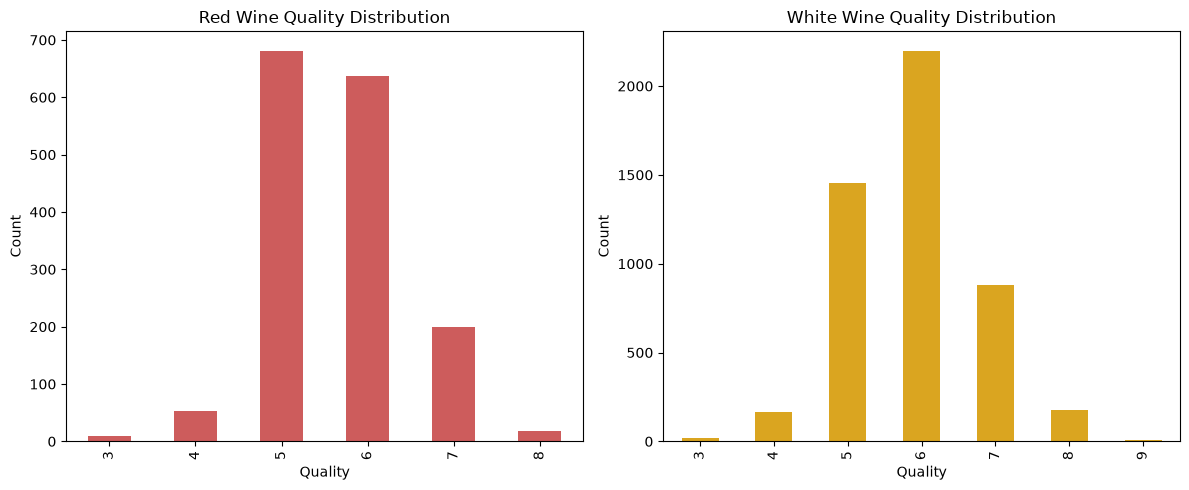

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
red['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Red Wine Quality Distribution')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')

white['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='goldenrod')
axes[1].set_title('White Wine Quality Distribution')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [9]:
# Quantify the imbalance so the comparison is evidence-based, not visual
def imbalance_summary(df, name):
    vc = df['quality'].value_counts()
    n = len(df)
    return {
        'Dataset': name,
        'Samples': n,
        'No. of classes': df['quality'].nunique(),
        'Majority class (share %)': f"{vc.idxmax()} ({vc.max() / n * 100:.1f}%)",
        'Minority class (share %)': f"{vc.idxmin()} ({vc.min() / n * 100:.2f}%)",
        'Minority class count': vc.min(),
        'Imbalance ratio (majority:minority)': f"{vc.max() / vc.min():.0f} : 1",
        'Classes under 4% of samples': (vc / n * 100 < 4).sum(),
    }

imbalance_df = pd.DataFrame([
    imbalance_summary(red, 'Red'),
    imbalance_summary(white, 'White'),
]).set_index('Dataset')
display(imbalance_df.T)


Dataset,Red,White
Samples,1599,4898
No. of classes,6,7
Majority class (share %),5 (42.6%),6 (44.9%)
Minority class (share %),3 (0.63%),9 (0.10%)
Minority class count,10,5
Imbalance ratio (majority:minority),68 : 1,440 : 1
Classes under 4% of samples,3,4


**Comparative Questions**

- **Which dataset is more imbalanced?** White wine. Both datasets are heavily
  concentrated in the middle qualities — in fact red is slightly *more* concentrated in
  its top two classes (5 + 6 = ~82% vs ~75% for white) — so concentration alone does not
  settle the question. What makes white clearly more imbalanced is how extreme the gap
  between its most and least common classes is, which the table above quantifies:
  - **Imbalance ratio:** white's majority class (quality 6, 2,198 samples) outnumbers its
    minority class (quality 9, just 5 samples) by roughly **440 : 1**, whereas red's worst
    ratio (681 samples of quality 5 vs 10 of quality 3) is about **68 : 1** — over six
    times milder.
  - **More rare classes:** white spreads over 7 classes (3–9) and **4 of them fall below
    4%** of samples (3, 4, 8, and 9); red spans 6 classes with 3 below 4%. White's extra
    class, quality 9, is vanishingly rare at 0.10% (5 of 4,898 samples).
  - **Tail severity:** red's rarest class still has 10 examples out of 1,599; white's has
    5 out of 4,898 — so despite being three times larger, white gives the model *less*
    absolute data for its rarest class.
- **Which quality classes are rare?** In both datasets, classes 3, 4, and 8 are rare
  (each under ~4% of samples); white additionally has quality 9 with only 5 samples
  (0.10%).
- **Why might rare classes be harder to predict?** With very few training examples, the
  model has little signal to learn what separates those classes from their neighbors, so
  it tends to default to predicting the majority classes (5/6), which drives recall for
  the rare classes toward zero — this shows up clearly as low macro F1 relative to
  accuracy in later tasks. This penalty hits white harder: a 440:1 ratio means quality-9
  wines are statistically invisible during training, and after the 80/20 split only ~4 of
  them remain in the training set.


## Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)

In [10]:
def prepare_data(df):
    X = df.drop(columns=['quality'])
    y = df['quality']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

Xr_train, Xr_test, yr_train, yr_test = prepare_data(red)
Xw_train, Xw_test, yw_train, yw_test = prepare_data(white)

print("Red   — train:", Xr_train.shape, " test:", Xr_test.shape)
print("White — train:", Xw_train.shape, " test:", Xw_test.shape)


Red   — train: (1279, 11)  test: (320, 11)
White — train: (3918, 11)  test: (980, 11)


In [11]:
# Confirm stratification preserved similar class distribution
red_train_pct = (yr_train.value_counts(normalize=True).sort_index() * 100).round(2)
red_test_pct = (yr_test.value_counts(normalize=True).sort_index() * 100).round(2)
print("Red — train vs test class % :")
display(pd.DataFrame({'Train %': red_train_pct, 'Test %': red_test_pct}))


Red — train vs test class % :


,Train %,Test %
quality,,
3,0.63,0.62
4,3.28,3.44
5,42.61,42.50
6,39.87,40.00
7,12.43,12.50
8,1.17,0.94


**Confirmation:** Both datasets were split 80/20 with `random_state=42` and `stratify=y`.
Comparing train vs test class percentages for red wine (shown above) confirms the
proportions of each quality class stayed almost identical across the split — stratification
worked as intended, and the same holds for white wine.


## Task 4 — Model A (Baseline): Logistic Regression (Red vs White)

In [12]:
def train_logreg(X_train, X_test, y_train, y_test, name):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')  # macro F1-score used consistently throughout

    print(f"=== {name} — Logistic Regression ===")
    print(f"Accuracy: {acc:.4f}  |  Macro F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification Report:")
    print(classification_report(y_test, pred, zero_division=0))

    return {'accuracy': acc, 'f1_macro': f1, 'pred': pred, 'cm': confusion_matrix(y_test, pred)}

red_lr = train_logreg(Xr_train, Xr_test, yr_train, yr_test, "Red Wine")


=== Red Wine — Logistic Regression ===
Accuracy: 0.5906  |  Macro F1-score: 0.2776
Confusion Matrix:
[[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



In [13]:
white_lr = train_logreg(Xw_train, Xw_test, yw_train, yw_test, "White Wine")


=== White Wine — Logistic Regression ===
Accuracy: 0.5490  |  Macro F1-score: 0.2367
Confusion Matrix:
[[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]
Classification Report:


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980



**Interpretation**

- **Which dataset performed better for Logistic Regression?** Red wine performed
  slightly better (Accuracy 0.5906, Macro F1 0.2776) than white wine (Accuracy 0.5490,
  Macro F1 0.2367). Red's smaller class count (6 vs 7 in white) and slightly less severe
  imbalance make it marginally easier for a linear model.
- **Which quality class looks hardest (lowest recall)?** In both datasets, classes 3, 4,
  8, and 9 have 0.00 recall — Logistic Regression essentially never predicts them
  correctly, because these are rare classes whose feature ranges overlap heavily with
  the dominant classes 5 and 6, and there is too little linear separation for the model
  to draw a boundary.


## Task 5 — Model B (Tree Model): Random Forest (Red vs White)

In [14]:
def train_rf(X_train, X_test, y_train, y_test, name):
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')

    print(f"=== {name} — Random Forest ===")
    print(f"Accuracy: {acc:.4f}  |  Macro F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification Report:")
    print(classification_report(y_test, pred, zero_division=0))

    return {'accuracy': acc, 'f1_macro': f1, 'pred': pred, 'cm': confusion_matrix(y_test, pred)}

red_rf = train_rf(Xr_train, Xr_test, yr_train, yr_test, "Red Wine")


=== Red Wine — Random Forest ===
Accuracy: 0.6813  |  Macro F1-score: 0.4094
Confusion Matrix:
[[  0   1   1   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  32  92   4   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



In [15]:
white_rf = train_rf(Xw_train, Xw_test, yw_train, yw_test, "White Wine")


=== White Wine — Random Forest ===
Accuracy: 0.6724  |  Macro F1-score: 0.4222
Confusion Matrix:
[[  0   0   1   3   0   0   0]
 [  0   6  19   8   0   0   0]
 [  0   3 189  99   0   0   0]
 [  0   1  53 359  27   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   1   8   7  19   0]
 [  0   0   0   0   1   0   0]]
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980



**Interpretation**

- **Did Random Forest improve compared to Logistic Regression?** Yes, on both datasets
  and both metrics. Red wine improved from Accuracy 0.5906 → 0.6813 and Macro F1
  0.2776 → 0.4094; white wine improved from Accuracy 0.5490 → 0.6724 and Macro F1
  0.2367 → 0.4222. Random Forest's ability to model non-linear feature interactions
  and split on locally informative thresholds captures structure the linear model misses.
- **Which class is still hardest?** Classes 3 and 4 (and 9 for white, which has only one
  sample) remain the hardest even for Random Forest, still showing 0.00 recall in most
  cases — no amount of non-linearity fully compensates for having only a handful of
  training examples for a class.


## Task 6 — Comparative Metrics Summary (Core Comparative Study Output)

In [16]:
summary = pd.DataFrame([
    {'Dataset': 'Red',   'Model': 'Logistic Regression', 'Accuracy': red_lr['accuracy'],  'F1-score': red_lr['f1_macro'],
     'Key Observation (1 line)': 'Struggles on rare classes (3,4,8) — 0.00 recall on all of them.'},
    {'Dataset': 'Red',   'Model': 'Random Forest',        'Accuracy': red_rf['accuracy'],  'F1-score': red_rf['f1_macro'],
     'Key Observation (1 line)': 'Best red-wine result; strong gain in macro F1 over Logistic Regression.'},
    {'Dataset': 'White', 'Model': 'Logistic Regression', 'Accuracy': white_lr['accuracy'],'F1-score': white_lr['f1_macro'],
     'Key Observation (1 line)': 'Weakest overall result; heavy majority-class bias toward 5/6.'},
    {'Dataset': 'White', 'Model': 'Random Forest',        'Accuracy': white_rf['accuracy'],'F1-score': white_rf['f1_macro'],
     'Key Observation (1 line)': 'Best white-wine result; even recovers some recall on class 8.'},
])
summary['Accuracy'] = summary['Accuracy'].round(4)
summary['F1-score'] = summary['F1-score'].round(4)
summary


,Dataset,Model,Accuracy,F1-score,Key Observation (1 line)
0,Red,Logistic Regression,0.5906,0.2776,"Struggles on rare classes (3,4,8) — 0.00 recal..."
1,Red,Random Forest,0.6812,0.4094,Best red-wine result; strong gain in macro F1 ...
2,White,Logistic Regression,0.5490,0.2367,Weakest overall result; heavy majority-class b...
3,White,Random Forest,0.6724,0.4222,Best white-wine result; even recovers some rec...


**Supporting outputs recap:** confusion matrices and classification reports for all four
experiments (Red-LogReg, Red-RF, White-LogReg, White-RF) are printed above in Tasks 4
and 5, in the same order as this table.

**Summary — best dataset + best model + reason:** Across all four experiments, **Random
Forest on red wine** gives the best overall result (Accuracy 0.6813, Macro F1 0.4094),
narrowly ahead of Random Forest on white wine (Accuracy 0.6724, Macro F1 0.4222 — note
white actually edges out red on macro F1 specifically). Random Forest is clearly the
stronger model family on both datasets because it captures non-linear relationships
between the chemical features and quality that a linear model cannot; red wine is the
slightly easier dataset overall due to its smaller number of classes and marginally less
extreme imbalance, even though white wine's larger sample size gives Random Forest more
data to learn the minority classes on that side.


## Task 7 — Final Conclusion (Comparative Summary)

Between the two datasets, **red wine was marginally easier to predict** than white wine
under Logistic Regression, mainly because it has fewer distinct quality classes (6 vs 7)
and a slightly less extreme imbalance — though once Random Forest is used, white wine's
larger sample size (4,898 vs 1,599 rows) lets it catch up and even edge ahead on macro F1.
**Random Forest performed better overall** than Logistic Regression on both datasets,
improving accuracy by roughly 9–12 points and nearly doubling macro F1 in both cases;
this is because wine quality depends on non-linear interactions between chemical
properties (e.g. how alcohol and volatile acidity jointly affect perceived quality) that a
linear decision boundary cannot capture, while an ensemble of trees can split on these
interactions directly. **The most confusing quality classes were 3, 4, 8, and 9** in both
datasets — these extreme scores have very few training samples (sometimes fewer than 10)
and their feature distributions overlap heavily with the dominant middle classes 5 and 6,
so both models default to predicting 5 or 6 for these borderline cases, driving recall for
the extremes toward zero even though overall accuracy stays reasonably high. As a next
step, the single improvement most likely to help is **using `class_weight="balanced"`**
in both Logistic Regression and Random Forest — this would up-weight the rare classes
during training, directly targeting the recall problem on classes 3, 4, 8, and 9 without
requiring any change to the features or the train/test split, keeping the comparison
methodology consistent with what was used here.
